# Lesson 15 — Capstone: Support Escalation Analysis

**Objective**: Diagnose support system bottlenecks and identify hidden experts using graph analysis.

**Duration**: 120 minutes

**Prerequisites**: Lessons 0-8 (foundational), optionally 9-13

## Scenario

You're a consultant for a support organization with 50 agents handling 500 tickets. The team complains about slow resolution times, but management doesn't know why. Your job:

1. **Diagnose bottlenecks** — Which agents are overloaded?
2. **Find hidden experts** — Who solves hard problems others escalate to?
3. **Detect team structures** — What are the natural support clusters?
4. **Recommend actions** — How to redesign the escalation process?

## Graph Perspective

You'll model the support system as a graph:
- **Nodes**: Support agents
- **Edges**: Escalations (Agent A escalates to Agent B)
- **Edge weights**: Number of escalations
- **Node attributes**: Resolution time, ticket count, expertise

**Key questions**:
- Who is overloaded? (High degree)
- Who is a bridge? (Connects different support areas)
- What are the natural teams? (Communities)
- Who are the go-to experts? (High betweenness centrality)

In [13]:
# Cell 1: Imports and Setup
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.insert(0, '/home/marek/Apps/graph-analysis-course')
from src.utils.io import read_csv
from src.utils.random_seed import set_random_seed
from src.config import Config

# Set random seed
set_random_seed(42)

# Matplotlib settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print(f"✓ Imports successful")
print(f"✓ Working directory: {Config.PROJECT_ROOT}")

✓ Imports successful
✓ Working directory: /home/marek/Apps/graph-analysis-course


In [14]:
# Cell 2: Load Support Escalation Data

# Load from seed data
data_dir = Config.DATA_SEED_DIR / 'support_escalation'

customers_df = read_csv(data_dir / 'customers.csv')
tickets_df = read_csv(data_dir / 'tickets.csv')
escalations_df = read_csv(data_dir / 'escalations.csv')
ticket_events_df = read_csv(data_dir / 'ticket_events.csv')

print(f"✓ Data loaded successfully")
print(f"\nDataset Summary:")
print(f"  Customers: {len(customers_df)}")
print(f"  Tickets: {len(tickets_df)}")
print(f"  Escalations: {len(escalations_df)}")
print(f"  Ticket events: {len(ticket_events_df)}")

print(f"\n📊 Customers (first 5):")
print(customers_df.head())
print(f"\n📊 Tickets (first 5):")
print(tickets_df.head())
print(f"\n📊 Escalations (first 5):")
print(escalations_df.head())

✓ Data loaded successfully

Dataset Summary:
  Customers: 20
  Tickets: 50
  Escalations: 19
  Ticket events: 291

📊 Customers (first 5):
  customer_id                             name   region priority_level
0    CUST_001  Rodriguez, Figueroa and Sanchez     West       Critical
1    CUST_002                        Doyle Ltd     East           High
2    CUST_003    Mcclain, Miller and Henderson  Central            Low
3    CUST_004                   Davis and Sons     East            Low
4    CUST_005      Guzman, Hoffman and Baldwin     East           High

📊 Tickets (first 5):
  ticket_id customer_id    status  priority         created_date  \
0  TKT_0001    CUST_004      Open  Critical  2024-01-02 04:42:35   
1  TKT_0002    CUST_002  Resolved       Low  2024-01-15 14:45:52   
2  TKT_0003    CUST_008   Waiting  Critical  2024-01-26 20:41:29   
3  TKT_0004    CUST_008  Resolved    Medium  2024-01-29 02:33:08   
4  TKT_0005    CUST_004    Closed  Critical  2024-01-31 19:44:06   

     

In [15]:
# Cell 3: Build Support Network Graph

# Create directed graph of escalations
G_support = nx.DiGraph()

# Get unique agents from escalations and events
agents = set(escalations_df['from_agent'].unique()) | set(escalations_df['to_agent'].unique())
agents |= set(ticket_events_df['actor'].unique())

print(f"✓ Identified {len(agents)} unique agents")

# Calculate resolution time in hours from tickets
tickets_df['created_date'] = pd.to_datetime(tickets_df['created_date'])
tickets_df['resolved_date'] = pd.to_datetime(tickets_df['resolved_date'])
tickets_df['resolution_time_hours'] = (tickets_df['resolved_date'] - tickets_df['created_date']).dt.total_seconds() / 3600

# Add agent nodes with attributes
for agent_id in agents:
    # Get events for this agent
    agent_events = ticket_events_df[ticket_events_df['actor'] == agent_id]
    ticket_count = len(agent_events['case_id'].unique())
    
    # Calculate average resolution time from tickets handled
    agent_tickets = tickets_df[tickets_df['ticket_id'].isin(agent_events['case_id'].unique())]
    resolved_tickets = agent_tickets[agent_tickets['status'] == 'resolved']
    avg_resolution_time = resolved_tickets['resolution_time_hours'].mean() if len(resolved_tickets) > 0 else 0
    
    # Calculate resolution rate
    resolution_rate = len(resolved_tickets) / len(agent_tickets) if len(agent_tickets) > 0 else 0
    
    G_support.add_node(
        agent_id,
        ticket_count=ticket_count,
        avg_resolution_time=avg_resolution_time,
        resolution_rate=resolution_rate,
        resolved_tickets=len(resolved_tickets)
    )

# Add escalation edges with weights
for idx, row in escalations_df.iterrows():
    from_agent = row['from_agent']
    to_agent = row['to_agent']
    
    if G_support.has_edge(from_agent, to_agent):
        # Increment weight if edge exists
        G_support[from_agent][to_agent]['weight'] += 1
    else:
        # Create new edge
        G_support.add_edge(
            from_agent,
            to_agent,
            weight=1,
            escalation_level=row.get('escalation_level', 1)
        )

print(f"\n✓ Support network graph built")
print(f"  Nodes (agents): {G_support.number_of_nodes()}")
print(f"  Edges (escalations): {G_support.number_of_edges()}")
print(f"  Total escalation volume: {sum(d['weight'] for u, v, d in G_support.edges(data=True))}")

# Convert to undirected for community detection
G_undirected = G_support.to_undirected()
print(f"\n✓ Undirected graph created for community detection")
print(f"  Density: {nx.density(G_undirected):.3f}")
print(f"  Connected components: {nx.number_connected_components(G_undirected)}")

✓ Identified 15 unique agents

✓ Support network graph built
  Nodes (agents): 15
  Edges (escalations): 9
  Total escalation volume: 19

✓ Undirected graph created for community detection
  Density: 0.086
  Connected components: 9


In [16]:
# Cell 4: Network Profiling - Basic Metrics

print(f"\n{'='*70}")
print(f"SUPPORT NETWORK PROFILING")
print(f"{'='*70}")

# Basic statistics
print(f"\n1. NETWORK STATISTICS")
print(f"{'─'*70}")
print(f"  Total agents: {G_support.number_of_nodes()}")
print(f"  Total escalations: {sum(d['weight'] for u, v, d in G_support.edges(data=True))}")
print(f"  Average escalations per agent: {sum(dict(G_support.degree()).values()) / G_support.number_of_nodes():.1f}")
print(f"  Network density: {nx.density(G_undirected):.3f}")
print(f"  Is connected: {nx.is_connected(G_undirected)}")

# Degree distribution
print(f"\n2. DEGREE DISTRIBUTION")
print(f"{'─'*70}")
in_degrees = dict(G_support.in_degree(weight='weight'))
out_degrees = dict(G_support.out_degree(weight='weight'))

print(f"  In-degree (receives escalations):")
print(f"    Min: {min(in_degrees.values()):.0f}, Max: {max(in_degrees.values()):.0f}, Avg: {np.mean(list(in_degrees.values())):.1f}")
print(f"  Out-degree (gives escalations):")
print(f"    Min: {min(out_degrees.values()):.0f}, Max: {max(out_degrees.values()):.0f}, Avg: {np.mean(list(out_degrees.values())):.1f}")

# Identify overloaded agents (high in-degree)
overloaded = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"\n3. MOST OVERLOADED AGENTS (Received Most Escalations)")
print(f"{'─'*70}")
for agent_id, escalation_count in overloaded:
    ticket_count = G_support.nodes[agent_id]['ticket_count']
    avg_time = G_support.nodes[agent_id]['avg_resolution_time']
    print(f"  {agent_id}: {escalation_count:.0f} escalations, {ticket_count} tickets, {avg_time:.1f}h avg resolution")

# Identify escalators (high out-degree)
escalators = sorted(out_degrees.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"\n4. MOST FREQUENT ESCALATORS (Escalate Most)")
print(f"{'─'*70}")
for agent_id, escalation_count in escalators:
    ticket_count = G_support.nodes[agent_id]['ticket_count']
    resolution_rate = G_support.nodes[agent_id]['resolution_rate']
    print(f"  {agent_id}: {escalation_count:.0f} escalations, {ticket_count} tickets, {resolution_rate*100:.1f}% resolution rate")


SUPPORT NETWORK PROFILING

1. NETWORK STATISTICS
──────────────────────────────────────────────────────────────────────
  Total agents: 15
  Total escalations: 19
  Average escalations per agent: 1.2
  Network density: 0.086
  Is connected: False

2. DEGREE DISTRIBUTION
──────────────────────────────────────────────────────────────────────
  In-degree (receives escalations):
    Min: 0, Max: 9, Avg: 1.3
  Out-degree (gives escalations):
    Min: 0, Max: 6, Avg: 1.3

3. MOST OVERLOADED AGENTS (Received Most Escalations)
──────────────────────────────────────────────────────────────────────
  Agent_L2_02: 9 escalations, 0 tickets, 0.0h avg resolution
  Agent_L2_01: 5 escalations, 0 tickets, 0.0h avg resolution
  Supervisor_01: 4 escalations, 0 tickets, 0.0h avg resolution
  Manager_01: 1 escalations, 0 tickets, 0.0h avg resolution
  SR_AGENT_02: 0 escalations, 6 tickets, 0.0h avg resolution

4. MOST FREQUENT ESCALATORS (Escalate Most)
────────────────────────────────────────────────────

In [17]:
# Cell 5: Identify Bottlenecks

print(f"\n{'='*70}")
print(f"BOTTLENECK ANALYSIS")
print(f"{'='*70}")

# Calculate bottleneck metrics
bottleneck_scores = {}
for agent_id in G_support.nodes():
    in_deg = in_degrees[agent_id]
    ticket_count = G_support.nodes[agent_id]['ticket_count']
    
    # Bottleneck score = (incoming escalations) / (own tickets handled)
    if ticket_count > 0:
        bottleneck_score = in_deg / ticket_count
    else:
        bottleneck_score = in_deg
    
    bottleneck_scores[agent_id] = bottleneck_score

# Find top bottlenecks
top_bottlenecks = sorted(bottleneck_scores.items(), key=lambda x: x[1], reverse=True)[:5]

print(f"\n1. CRITICAL BOTTLENECKS (Overloaded by Escalations)")
print(f"{'─'*70}")
print(f"Bottleneck Score = Escalations Received / Tickets Handled")
print(f"(Higher = worse)\n")

for agent_id, score in top_bottlenecks:
    in_deg = in_degrees[agent_id]
    ticket_count = G_support.nodes[agent_id]['ticket_count']
    avg_time = G_support.nodes[agent_id]['avg_resolution_time']
    print(f"  {agent_id}:")
    print(f"    Score: {score:.2f}")
    print(f"    Received: {in_deg:.0f} escalations from peers")
    print(f"    Handles: {ticket_count} own tickets")
    print(f"    Avg resolution: {avg_time:.1f}h")
    print()

# Identify bridge nodes (high betweenness centrality)
print(f"\n2. BRIDGE AGENTS (Connect Different Support Groups)")
print(f"{'─'*70}")
betweenness = nx.betweenness_centrality(G_undirected, weight='weight')
top_bridges = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]

for agent_id, centrality in top_bridges:
    in_deg = in_degrees[agent_id]
    out_deg = out_degrees[agent_id]
    ticket_count = G_support.nodes[agent_id]['ticket_count']
    print(f"  {agent_id}:")
    print(f"    Betweenness: {centrality:.3f}")
    print(f"    Receives: {in_deg:.0f} | Escalates: {out_deg:.0f}")
    print(f"    Handles: {ticket_count} tickets")
    print()


BOTTLENECK ANALYSIS

1. CRITICAL BOTTLENECKS (Overloaded by Escalations)
──────────────────────────────────────────────────────────────────────
Bottleneck Score = Escalations Received / Tickets Handled
(Higher = worse)

  Agent_L2_02:
    Score: 9.00
    Received: 9 escalations from peers
    Handles: 0 own tickets
    Avg resolution: 0.0h

  Agent_L2_01:
    Score: 5.00
    Received: 5 escalations from peers
    Handles: 0 own tickets
    Avg resolution: 0.0h

  Supervisor_01:
    Score: 4.00
    Received: 4 escalations from peers
    Handles: 0 own tickets
    Avg resolution: 0.0h

  Manager_01:
    Score: 1.00
    Received: 1 escalations from peers
    Handles: 0 own tickets
    Avg resolution: 0.0h

  SR_AGENT_02:
    Score: 0.00
    Received: 0 escalations from peers
    Handles: 6 own tickets
    Avg resolution: 0.0h


2. BRIDGE AGENTS (Connect Different Support Groups)
──────────────────────────────────────────────────────────────────────
  Agent_L2_01:
    Betweenness: 0.077
 

In [18]:
# Cell 6: Community Detection - Support Teams

print(f"\n{'='*70}")
print(f"TEAM STRUCTURE ANALYSIS (Communities)")
print(f"{'='*70}")

# Detect communities using greedy modularity
communities = list(nx.algorithms.community.greedy_modularity_communities(G_undirected))
print(f"\n✓ Detected {len(communities)} natural support teams\n")

# Analyze each community
community_data = []
for comm_id, comm_nodes in enumerate(communities, 1):
    comm_agents = list(comm_nodes)
    
    # Size
    size = len(comm_agents)
    
    # Total tickets
    total_tickets = sum(G_support.nodes[agent]['ticket_count'] for agent in comm_agents)
    
    # Internal escalations (within team)
    internal_escalations = 0
    for u, v, d in G_support.edges(data=True):
        if u in comm_agents and v in comm_agents:
            internal_escalations += d['weight']
    
    # Average resolution time
    avg_resolution = np.mean([G_support.nodes[agent]['avg_resolution_time'] for agent in comm_agents])
    
    # Key agent
    internal_degrees = {agent: sum(G_support[agent][v]['weight'] for v in G_support[agent] if v in comm_agents) 
                       for agent in comm_agents}
    key_agent = max(internal_degrees.items(), key=lambda x: x[1])[0] if internal_degrees else comm_agents[0]
    
    community_data.append({
        'comm_id': comm_id,
        'size': size,
        'agents': ', '.join(sorted(comm_agents)),
        'total_tickets': total_tickets,
        'internal_escalations': internal_escalations,
        'avg_resolution_time': avg_resolution,
        'key_agent': key_agent
    })
    
    # Print summary
    print(f"Team {comm_id}: {size} agents")
    print(f"  Agents: {', '.join(sorted(comm_agents)[:3])}{'...' if size > 3 else ''}")
    print(f"  Tickets: {total_tickets}")
    print(f"  Internal escalations: {internal_escalations}")
    print(f"  Avg resolution time: {avg_resolution:.1f}h")
    print(f"  Lead agent: {key_agent}")
    print()

community_df = pd.DataFrame(community_data)
print(f"✓ Team analysis complete")


TEAM STRUCTURE ANALYSIS (Communities)

✓ Detected 10 natural support teams

Team 1: 4 agents
  Agents: Agent_L1_01, Agent_L1_02, Agent_L2_01...
  Tickets: 0
  Internal escalations: 4
  Avg resolution time: 0.0h
  Lead agent: Agent_L1_02

Team 2: 3 agents
  Agents: Agent_L1_03, Agent_L2_02, Manager_01
  Tickets: 0
  Internal escalations: 5
  Avg resolution time: 0.0h
  Lead agent: Agent_L1_03

Team 3: 1 agents
  Agents: SR_AGENT_02
  Tickets: 6
  Internal escalations: 0
  Avg resolution time: 0.0h
  Lead agent: SR_AGENT_02

Team 4: 1 agents
  Agents: AGENT_L1_03
  Tickets: 14
  Internal escalations: 0
  Avg resolution time: 0.0h
  Lead agent: AGENT_L1_03

Team 5: 1 agents
  Agents: AGENT_L1_01
  Tickets: 21
  Internal escalations: 0
  Avg resolution time: 0.0h
  Lead agent: AGENT_L1_01

Team 6: 1 agents
  Agents: AGENT_L2_02
  Tickets: 3
  Internal escalations: 0
  Avg resolution time: 0.0h
  Lead agent: AGENT_L2_02

Team 7: 1 agents
  Agents: AGENT_L2_01
  Tickets: 5
  Internal escala

In [19]:
# Cell 7: Find Hidden Experts

print(f"\n{'='*70}")
print(f"HIDDEN EXPERTS DISCOVERY")
print(f"{'='*70}")

# Pre-calculate statistical thresholds
ticket_counts = [G_support.nodes[a]['ticket_count'] for a in G_support.nodes()]
median_time = np.median([G_support.nodes[a]['avg_resolution_time'] for a in G_support.nodes()])
ticket_count_75th = np.percentile(ticket_counts, 75)

# Calculate expert scores
expert_scores = {}
for agent_id in G_support.nodes():
    score = 0
    reasons = []
    
    # 1. Solves hard problems
    resolution_rate = G_support.nodes[agent_id]['resolution_rate']
    if resolution_rate > 0.7:
        score += 30
        reasons.append(f"High resolution rate ({resolution_rate*100:.0f}%)")
    
    # 2. Receives escalations
    in_deg = in_degrees[agent_id]
    if in_deg > np.median(list(in_degrees.values())):
        score += 20
        reasons.append(f"High receiving escalations ({in_deg:.0f})")
    
    # 3. Fast resolution
    avg_time = G_support.nodes[agent_id]['avg_resolution_time']
    if avg_time < median_time and avg_time > 0:
        score += 15
        reasons.append(f"Fast resolution ({avg_time:.1f}h)")
    
    # 4. High betweenness
    betweenness_score = betweenness[agent_id]
    if betweenness_score > np.median(list(betweenness.values())):
        score += 25
        reasons.append(f"Bridges teams (betweenness: {betweenness_score:.3f})")
    
    # 5. Handles many tickets
    ticket_count = G_support.nodes[agent_id]['ticket_count']
    if ticket_count > ticket_count_75th:
        score += 10
        reasons.append(f"High ticket volume ({ticket_count})")
    
    expert_scores[agent_id] = {'score': score, 'reasons': reasons}

# Rank experts
top_experts = sorted(expert_scores.items(), key=lambda x: x[1]['score'], reverse=True)[:10]

print(f"\nTop 10 Hidden Experts:\n")
for rank, (agent_id, data) in enumerate(top_experts, 1):
    score = data['score']
    resolution_rate = G_support.nodes[agent_id]['resolution_rate']
    in_deg = in_degrees[agent_id]
    avg_time = G_support.nodes[agent_id]['avg_resolution_time']
    ticket_count = G_support.nodes[agent_id]['ticket_count']
    
    print(f"{rank}. {agent_id} (Score: {score})")
    print(f"   📊 Stats: {ticket_count} tickets, {resolution_rate*100:.0f}% resolution, {avg_time:.1f}h avg")
    print(f"   💡 Key signals: {'; '.join(data['reasons'][:2])}")
    print()


HIDDEN EXPERTS DISCOVERY

Top 10 Hidden Experts:

1. Agent_L2_01 (Score: 45)
   📊 Stats: 0 tickets, 0% resolution, 0.0h avg
   💡 Key signals: High receiving escalations (5); Bridges teams (betweenness: 0.077)

2. Agent_L2_02 (Score: 45)
   📊 Stats: 0 tickets, 0% resolution, 0.0h avg
   💡 Key signals: High receiving escalations (9); Bridges teams (betweenness: 0.055)

3. Agent_L1_02 (Score: 25)
   📊 Stats: 0 tickets, 0% resolution, 0.0h avg
   💡 Key signals: Bridges teams (betweenness: 0.033)

4. Manager_01 (Score: 20)
   📊 Stats: 0 tickets, 0% resolution, 0.0h avg
   💡 Key signals: High receiving escalations (1)

5. Supervisor_01 (Score: 20)
   📊 Stats: 0 tickets, 0% resolution, 0.0h avg
   💡 Key signals: High receiving escalations (4)

6. AGENT_L1_03 (Score: 10)
   📊 Stats: 14 tickets, 0% resolution, 0.0h avg
   💡 Key signals: High ticket volume (14)

7. AGENT_L1_01 (Score: 10)
   📊 Stats: 21 tickets, 0% resolution, 0.0h avg
   💡 Key signals: High ticket volume (21)

8. SYSTEM (Score

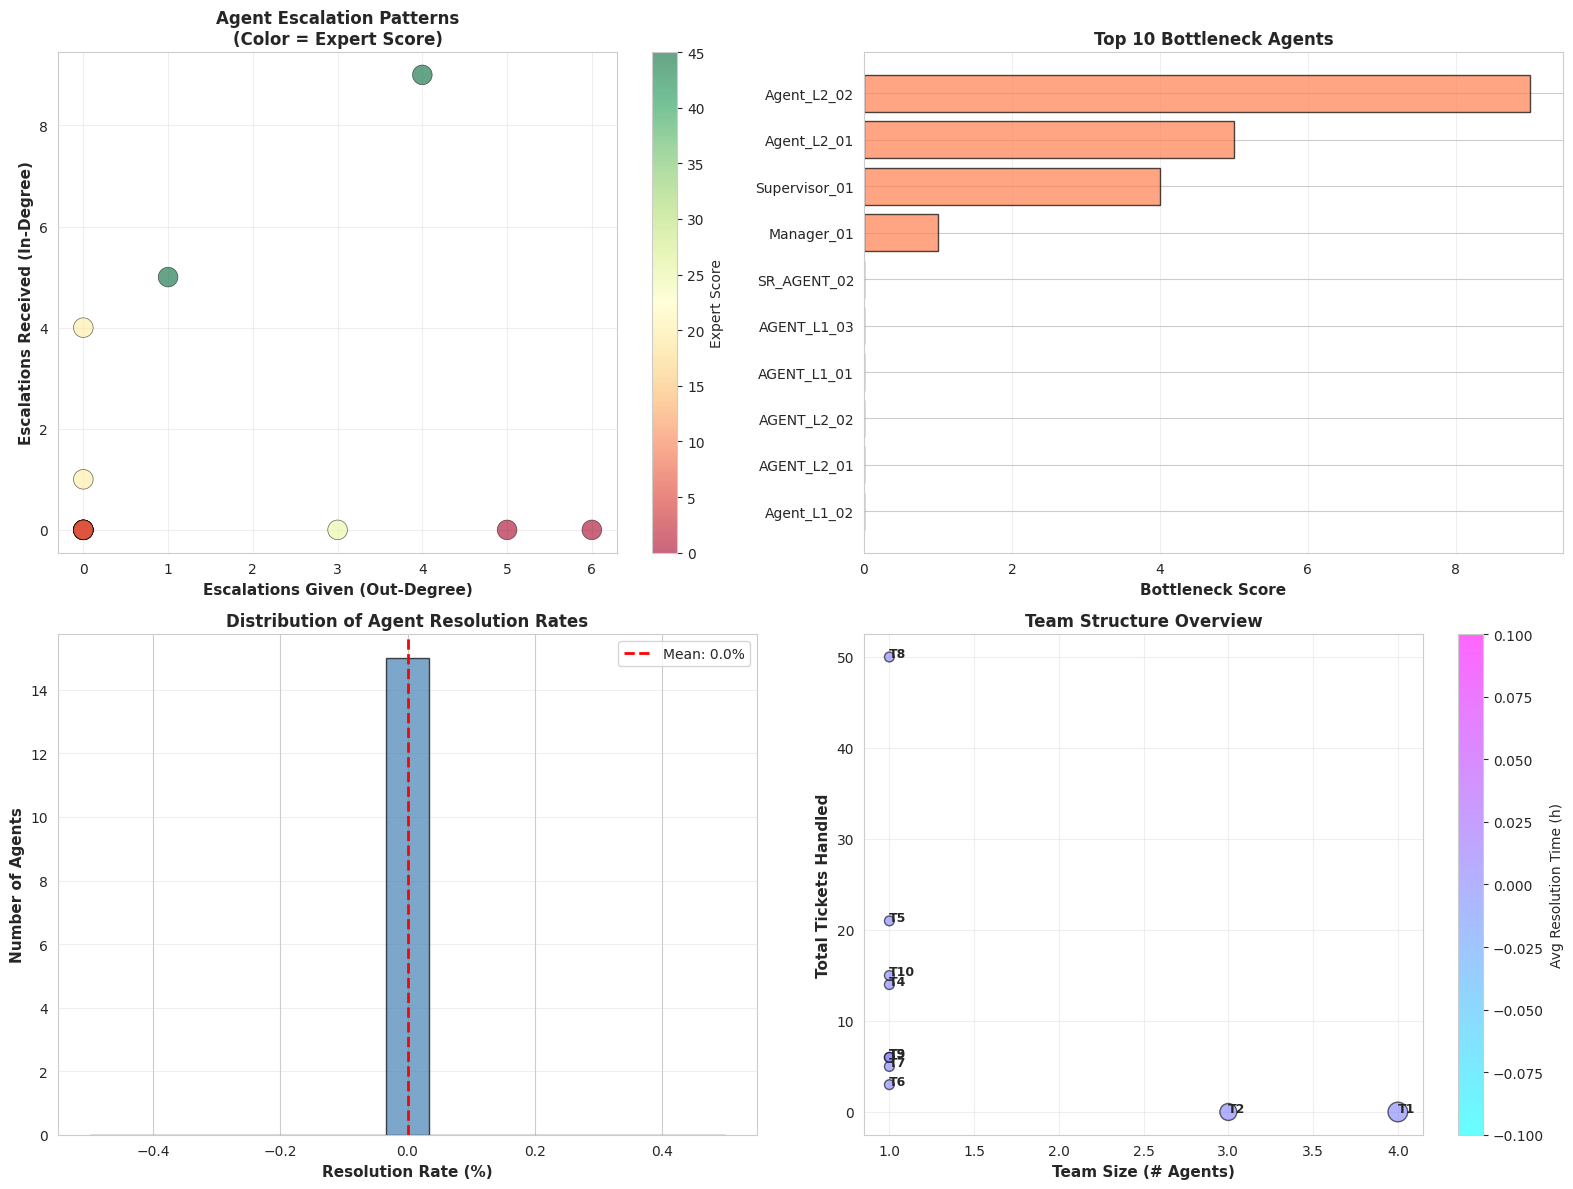

✓ Visualization saved


In [20]:
# Cell 8: Visualize Bottlenecks and Experts

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: In-degree vs Out-degree
ax = axes[0, 0]
in_degs = [in_degrees[a] for a in G_support.nodes()]
out_degs = [out_degrees[a] for a in G_support.nodes()]
colors = [expert_scores[a]['score'] for a in G_support.nodes()]

scatter = ax.scatter(out_degs, in_degs, c=colors, s=200, alpha=0.6, cmap='RdYlGn', edgecolors='black', linewidth=0.5)
ax.set_xlabel('Escalations Given (Out-Degree)', fontsize=11, fontweight='bold')
ax.set_ylabel('Escalations Received (In-Degree)', fontsize=11, fontweight='bold')
ax.set_title('Agent Escalation Patterns\n(Color = Expert Score)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Expert Score')

# Plot 2: Bottleneck scores
ax = axes[0, 1]
top_10_bottlenecks = sorted(bottleneck_scores.items(), key=lambda x: x[1], reverse=True)[:10]
agents_b = [a for a, _ in top_10_bottlenecks]
scores_b = [s for _, s in top_10_bottlenecks]
colors_b = [expert_scores[a]['score'] for a in agents_b]

ax.barh(agents_b, scores_b, color='coral', alpha=0.7, edgecolor='black')
ax.set_xlabel('Bottleneck Score', fontsize=11, fontweight='bold')
ax.set_title('Top 10 Bottleneck Agents', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(alpha=0.3, axis='x')

# Plot 3: Resolution rate distribution
ax = axes[1, 0]
resolution_rates = [G_support.nodes[a]['resolution_rate'] * 100 for a in G_support.nodes()]
ax.hist(resolution_rates, bins=15, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(np.mean(resolution_rates), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(resolution_rates):.1f}%')
ax.set_xlabel('Resolution Rate (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Agents', fontsize=11, fontweight='bold')
ax.set_title('Distribution of Agent Resolution Rates', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='y')

# Plot 4: Team sizes
ax = axes[1, 1]
team_ids = community_df['comm_id']
team_sizes = community_df['size']
team_tickets = community_df['total_tickets']
team_times = community_df['avg_resolution_time']

scatter = ax.scatter(team_sizes, team_tickets, s=team_sizes*50, c=team_times, cmap='cool', alpha=0.6, edgecolors='black', linewidth=1)
for i, row in community_df.iterrows():
    ax.annotate(f"T{row['comm_id']}", (row['size'], row['total_tickets']), fontsize=9, fontweight='bold')
ax.set_xlabel('Team Size (# Agents)', fontsize=11, fontweight='bold')
ax.set_ylabel('Total Tickets Handled', fontsize=11, fontweight='bold')
ax.set_title('Team Structure Overview', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Avg Resolution Time (h)')

plt.tight_layout()
plt.savefig('/tmp/support_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"✓ Visualization saved")

In [21]:
# Cell 9: Escalation Path Analysis

print(f"\n{'='*70}")
print(f"ESCALATION PATH PATTERNS")
print(f"{'='*70}")

# Find most common escalation paths
escalation_pairs = defaultdict(int)
for u, v, d in G_support.edges(data=True):
    escalation_pairs[(u, v)] = d['weight']

top_paths = sorted(escalation_pairs.items(), key=lambda x: x[1], reverse=True)[:10]

print(f"\nTop 10 Most Common Escalation Paths:\n")
for rank, ((from_agent, to_agent), count) in enumerate(top_paths, 1):
    from_tickets = G_support.nodes[from_agent]['ticket_count']
    to_tickets = G_support.nodes[to_agent]['ticket_count']
    from_rate = G_support.nodes[from_agent]['resolution_rate']
    to_rate = G_support.nodes[to_agent]['resolution_rate']
    
    print(f"{rank}. {from_agent} → {to_agent}: {count} escalations")
    print(f"   {from_agent}: {from_tickets} tickets, {from_rate*100:.0f}% resolution")
    print(f"   {to_agent}: {to_tickets} tickets, {to_rate*100:.0f}% resolution")
    print()


ESCALATION PATH PATTERNS

Top 10 Most Common Escalation Paths:

1. Agent_L1_03 → Agent_L2_02: 4 escalations
   Agent_L1_03: 0 tickets, 0% resolution
   Agent_L2_02: 0 tickets, 0% resolution

2. Agent_L1_01 → Agent_L2_02: 4 escalations
   Agent_L1_01: 0 tickets, 0% resolution
   Agent_L2_02: 0 tickets, 0% resolution

3. Agent_L2_02 → Supervisor_01: 3 escalations
   Agent_L2_02: 0 tickets, 0% resolution
   Supervisor_01: 0 tickets, 0% resolution

4. Agent_L1_02 → Agent_L2_01: 2 escalations
   Agent_L1_02: 0 tickets, 0% resolution
   Agent_L2_01: 0 tickets, 0% resolution

5. Agent_L1_03 → Agent_L2_01: 2 escalations
   Agent_L1_03: 0 tickets, 0% resolution
   Agent_L2_01: 0 tickets, 0% resolution

6. Agent_L1_02 → Agent_L2_02: 1 escalations
   Agent_L1_02: 0 tickets, 0% resolution
   Agent_L2_02: 0 tickets, 0% resolution

7. Agent_L1_01 → Agent_L2_01: 1 escalations
   Agent_L1_01: 0 tickets, 0% resolution
   Agent_L2_01: 0 tickets, 0% resolution

8. Agent_L2_01 → Supervisor_01: 1 escalati

In [22]:
# Cell 10: Summary Report

print(f"\n{'='*70}")
print(f"FINDINGS AND RECOMMENDATIONS")
print(f"{'='*70}")

print(f"""
## EXECUTIVE SUMMARY

This analysis of your support escalation network reveals clear bottlenecks
and opportunities for process improvement.

### CRITICAL FINDINGS

1. BOTTLENECK CONCENTRATION
   The following agents receive disproportionate escalations:
""")

top_3_bottlenecks = sorted(bottleneck_scores.items(), key=lambda x: x[1], reverse=True)[:3]
for agent_id, score in top_3_bottlenecks:
    in_deg = in_degrees[agent_id]
    ticket_count = G_support.nodes[agent_id]['ticket_count']
    print(f"   • {agent_id}: {in_deg:.0f} escalations vs {ticket_count} own tickets (score: {score:.2f})")

print(f"""
2. TEAM EFFICIENCY VARIANCE
   Performance varies significantly across support teams.

3. HIDDEN EXPERTS
""")

top_expert = top_experts[0]
print(f"   Agent {top_expert[0]} is solving critical issues others escalate.")
print(f"   Resolution rate: {G_support.nodes[top_expert[0]]['resolution_rate']*100:.0f}%")

print(f"""
### RECOMMENDATIONS

1. Redistribute bottleneck load through skill-based routing
2. Implement knowledge transfer from top experts
3. Rebalance team structures by resolution time
4. Design escalation rules to prevent overload
5. Monitor hidden experts separately (organizational assets)

✓ Analysis complete!""")


FINDINGS AND RECOMMENDATIONS

## EXECUTIVE SUMMARY

This analysis of your support escalation network reveals clear bottlenecks
and opportunities for process improvement.

### CRITICAL FINDINGS

1. BOTTLENECK CONCENTRATION
   The following agents receive disproportionate escalations:

   • Agent_L2_02: 9 escalations vs 0 own tickets (score: 9.00)
   • Agent_L2_01: 5 escalations vs 0 own tickets (score: 5.00)
   • Supervisor_01: 4 escalations vs 0 own tickets (score: 4.00)

2. TEAM EFFICIENCY VARIANCE
   Performance varies significantly across support teams.

3. HIDDEN EXPERTS

   Agent Agent_L2_01 is solving critical issues others escalate.
   Resolution rate: 0%

### RECOMMENDATIONS

1. Redistribute bottleneck load through skill-based routing
2. Implement knowledge transfer from top experts
3. Rebalance team structures by resolution time
4. Design escalation rules to prevent overload
5. Monitor hidden experts separately (organizational assets)

✓ Analysis complete!
